# **Build Skills from a Zenodo CSV Collection**

This notebook turns a folder of loosely-related **CSV files into a set of clean,
queryable ARGUS skills** — you write no data-loading code. Paste the Zenodo
record URL into a `%%skill-build` cell and ARGUS inventories the files, reads the
accompanying documentation for column meanings, and proposes a set of skills.

The interesting part here is that a real research record is rarely *one* table.
This record holds a dozen CSVs describing different things — community surveys,
incubation-chamber measurements, isotope samples, high-frequency sensor logs.
ARGUS groups the files by the **entity each one describes** and proposes several
focused skills rather than one muddled catalog.

**ARGUS pauses for your approval before building.** Deciding *how many skills
and which files go in each* is a judgement call, so ARGUS presents the proposed
grouping and stops. You reply `Yes` (or redirect the grouping) in the next cell,
and only then does it build.

The example dataset compares a natural high-CO₂ vent site against a nearby
reference site — a real-world window on how ocean acidification reshapes a
seafloor algal community. Source:
[zenodo.org/records/16653947](https://zenodo.org/records/16653947) · CC-BY-4.0 ·
Wada, S. (2025).


####   **Choose your language model**

Argus is model-agnostic — you can plug in any major LLM provider that offers a strong code-generation model. Pick whichever you have an API key for. To switch, comment out the active `LLM = {...}` block and uncomment the one you want.

**This notebook defaults to GLM-5 via the National Research Platform** (free for NRP users). If you don't have NRP access, swap in another provider — they all work the same way.

**Before you run the cell: save your API key as a Colab Secret**

Argus reads your API key from a Colab Secret, not from the notebook itself — that keeps the key out of your saved file and out of anyone you share the notebook with.

1. Click the 🔑 key icon in the left sidebar (**Secrets**).
2. Click **+ Add new secret**.
3. Set the **Name** to match the `api_key_env` value in your `LLM` block:
   - `NRP_API_KEY` for NRP-served models
   - `OPENAI_API_KEY` for OpenAI
   - `ANTHROPIC_API_KEY` for Anthropic
   - `GOOGLE_API_KEY` for Google
   - `ZAI_API_KEY` for Z.ai
4. Paste your key into the **Value** field.
5. Toggle **Notebook access** on for this notebook.

If the key isn't set (or notebook access is off), Argus will fail with an authentication error when it tries to call the model.

### Choosing a model

Argus generates and runs Python against real data on every turn. The model must be **excellent at coding** — not just capable of tool-calling. Chat-tuned models with strong conversational performance but weaker code generation produce Argus runs that fail on real datasets, retry many times, or drift into wordy exploration without converging.

**What to pick**: choose your provider's top-tier code-focused model — the one they market for agentic coding, software engineering, or long-context multi-step work. Avoid the chat-tuned default.

**Known quirks**: heavily-quantized model variants (4-bit weights or smaller) can complete workflows but with excess retries and lower-quality code. If you have the choice between quantized and full-precision for the same model, pick full-precision.

In [2]:
# Use GLM-5 from National Research Platform
# LLM = {
#     "model": "glm-5",
#     "url": "https://ellm.nrp-nautilus.io/v1",
#     "api_key_env": "NRP_API_KEY",
# }

# Use GPT-5.5 from OpenAI
# LLM = {
#     "model": "gpt-5.5",
#     "api_key_env": "OPENAI_API_KEY",
# }

# Use Claude Sonnet 4.6 from Anthropic
# LLM = {
#     "model": "claude-sonnet-4-6",
#     "api_key_env": "ANTHROPIC_API_KEY",
#     "flavor": "anthropic",
# }

# Use Gemini 3.5 Flash from Google
# LLM = {
#     "model": "gemini-3.5-flash",
#     "api_key_env": "GOOGLE_API_KEY",
#     "flavor": "gemini",
# }

# Use GLM-5 from ZAI
LLM = {
    "model": "glm-5",
    "url": "https://api.z.ai/api/coding/paas/v4",
    "api_key_env": "ZAI_API_KEY",
}

#### **Install Argus from GitHub Repo**

In [6]:
import urllib.request
exec(urllib.request.urlopen(
    'https://raw.githubusercontent.com/klinucsd/sage/main/argus_colab/install.py'
).read().decode(), globals())

ARGUS bootstrap starting...
  ✓ Wrote LLM config to /root/.deepagents/config.toml (added default params for 1 ChatOpenAI provider(s))
  ✓ Loaded ZAI_API_KEY from Colab Secrets
  ✓ ARGUS dependencies already installed
  ✓ Downloaded sage_magic.py + sage_kernel_backend.py from main
  ✓ Installed 2 core skill(s) into /root/.deepagents/agent/skills: array-skill-builder, zenodo-skill-builder
  · Skipped 13 core skill(s) (already present): arcgis-feature-skill-builder, ckan-skill-builder, ndp-search, ndp-skill-builder, repo-skill-builder, s3-skill-builder, sage-bbox-map, sage-dropdown, sage-metrics, skillsmp, tabular-skill-builder, us-counties, us-states

ARGUS ready — %%ask, %%mcp, %%skill are registered.
  Provider: llm  ·  Model: llm:glm-5


In [4]:
%reset

**Sage reset.** Output folder cleared, history cleared.

_To also clear cell outputs: click **Edit → Clear all outputs** (in the Colab menu bar)._

In [7]:
%%skill-build
https://zenodo.org/records/16653947

I'll build an ARGUS skill for the Zenodo record. The URL type (zenodo.org/records/<id>) matches the `zenodo-skill-builder` meta-skill. Let me read its instructions first.

The skill says to use `/home/jovyan/...` paths, but the system prompt overrides this: skills live under `/root/.deepagents/agent/skills/` and I must stage downloads in my working directory, not `/tmp`. Let me verify the fetch.py location and check the working directory.

fetch.py exists. There's a leftover `zenodo_resp.json` from a prior attempt — let me check it and review fetch.py's interface before running it.

Let me read the rest of fetch.py to understand its interface fully.

There's a leftover 403 response from a prior attempt — Zenodo may be rate-limiting. Let me finish reading fetch.py's routing logic, then run it.

...

Reading the rest of the SKILL.md (Steps 6–9) and running the tabular inventory in parallel.

Inventory complete: 12 CSVs in 10 schema groups. This is a marine-ecology dataset (algal coverage, δ13C isotopes, chamber experiments, DO sensor time series). Before proposing, I'll read the two .docx documentation files and the Zenodo metadata for semantics — one exploration script, as the rules allow.

python-docx didn't install via subprocess. A `.docx` is just a ZIP of XML — I'll extract the text directly without any library.

I now have the full scientific picture. This is a **coastal CO₂-vent ocean-acidification study** (Wada, Shigeki; Jeju Island benthic algal community) with two experiments: lab chamber incubations (Exp 1, with δ¹³C tracer) and in-situ chamber deployments with sensors (Exp 2). All 12 CSVs share `Season`/`Site` keys and total ~680 KB (bundle, not lazy-download). I'm at the Step 4 proposal gate — no build scripts, no SKILL.md, until you approve.

I've fetched and inspected Zenodo record **16653947** (ROUTE: tabular). Proposal below.

**Source:** "R code and csv files" — Wada, Shigeki (2025-07-31); CC-BY-4.0; DOI `10.5281/zenodo.16653947`. A coastal CO₂-vent ocean-acidification study of benthic algal communities (Jeju Island), with two experiments — lab chamber incubations with a ¹³C tracer (Exp 1) and in-situ chamber deployments with DO/light sensors (Exp 2).

**Files:** 12 CSVs (~680 KB total, 10 schema groups), 2 .docx (R analysis scripts read for semantics).

**Proposed skills:**

1. **`co2-vent-algal-community`** — each row is a quadrat transect observation of benthic algal species percent cover at a study site and season. From `Species coverage_recounted.csv` (130 rows, 38 cols incl. 30 named-species cover columns + functional groups) merged with `functionsigma13_230728.csv` (130 rows, weighted δ¹³C by functional group). Key columns: `Season`, `Site`, `Site No`, plus per-species cover (`Gelidium.elegans`, `Zonaria.diesingiana`, …) and functional-group δ¹³C. JOIN: `Season` + `Site No`.
2. **`co2-vent-chamber-incubations`** — each row is a chamber incubation measurement (net production, nutrient, carbonate chemistry, δ¹³C uptake) for a functional group at a site/season. From `ChamberNP.csv` (134), `ChamberEnv.csv` (86), `EnvData.csv` (4680), `13C species.csv` (277), `bothsitespecies13C.csv` (82), `DO vs time.csv` (94). Key columns: `Season`, `Site`, `Light`, `Temp`, `pCO2`, `pH`, `TA`, `NP` (net production), `delta_13C`. JOIN: `Season` + `Site` (+ `Function`/`Name` where present).
3. **`co2-vent-sensor-timeseries`** — each row is a timestamped sensor reading (DO per chamber 1–4, light, N/E current) from the in-situ deployed chambers. From `Sensors.csv` (4064 rows) merged with `Sensors_Irie.csv` (2760 rows, same schema — a second "Irie" site). Key columns: `Time`, `DO1`–`DO4`, `Light`, `North`, `East`. Adds a `source_site` discriminator from filename.

**Notes:**
- Functional-group summary tables (`Species coverage_function.csv`, `deploy_coverage_function.csv`) are 2-file schema-group B (14 cols). These are **near-matches** to skill 1's species table but a different grain (functional-group rollup vs species-level). I propose folding them into skill 1 as additional columns/rows keyed by `Season`+`Site`+`Function` rather than a separate skill — **please confirm** this is preferred over keeping them separate.
- `Season` is a string like `17-Jun`/`Pre`/`Post`/`Recovery`; I'll add parsed `Year`/`Month` columns where absent.
- `Site` codes `C`→Reference, `I`→High CO₂ (per the R script).
- Data: **bundle** (~680 KB, well under the ~100 MB threshold).

**Open questions:**
- Functional-group coverage tables (group B): fold into skill 1, or keep as a 4th skill?
- Skill 2 mixes several measurement types (NP, carbonate chemistry, δ¹³C, DO-vs-time). I can keep them in one skill (all share `Season`+`Site` incubation context) or split δ¹³C tracer results into their own skill. My default is one skill; confirm or split?

Reply **"yes"** to build as proposed, or with edits (e.g. "split skill 2", "4th skill for functional groups", "rename …").

(Resume state on disk: `/root/_13iLPg3gBaR-MpxwynClua7T1PA80Lj-F_sage_/zenodo-skills/16653947/` — the source CSVs, `_inventory.json`, `_zenodo_metadata.json`, and `_docs/` are all there.)

In [8]:
%%ask
Yes, please create these skills.

I'll build the three skills now. Let me set up a task list and read the build-phase conventions plus my inventory.

I have the build-phase rules and inventory structure. Let me read the rest of the SKILL.md (Steps 7-9: SKILL.md template, verification, cleanup) and the full inventory.

I have the full inventory (10 schema groups, 12 files, 0 unreadable) and the complete build-phase rules. Let me update my plan and write the build script.

Now I'll write the build script that merges and canonicalizes all three skills' data into Parquet caches.

Running the build script to merge and write the three Parquet caches.

...

Verifying all outputs, then cleaning scratch + source dir (Step 9).

All six outputs verified. Deleting scratch files and the source directory.

All clean. Now let me do the closing self-audit before writing the final report.

Closing self-audit: I had one edit-and-retry cycle — the build script's first run failed because `fastparquet` wasn't installed in the subprocess environment, then I installed it and re-ran. This fix is non-obvious (SKILL.md says to *use* the fastparquet engine but an agent can forget fastparquet may not be pre-installed). Recording the lesson now.

All three skills are built, verified, and the source directory is cleaned up. Here's the summary.

---

✓ Built skill **co2-vent-algal-community** at `_skills_/co2-vent-algal-community/SKILL.md`.

Each row is a quadrat survey of benthic algal community percent cover at a coastal CO₂ vent off Jeju Island (214 quadrat observations, 9 seasonal surveys across 2017–2018, ~30 named macroalgal species + functional groups).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| CO₂ exposure | `site_canonical` | `Reference`, `High CO2` |
| Survey grain | `survey_type` | `species_recount`, `deploy_functional` |
| Season | `Season` | `17-Jun`, `17-Nov`, `18-Apr`, `18-Oct` |
| Time | `year`, `month` | year 17/18; month 1,4,6,9,10,11,12 |
| Quadrat ID | `site_no` | `C2`, `C4`, `I7`, `I12` (62 distinct) |
| Functional group | `Crustose Coralline Algae`, `Canopy-forming algae`, `Bare Rock`, `Turf algae` | percent-cover columns |
| Carbon fixation | `weighted_13C` | δ¹³C ‰, range −20.8 to −8.29 |

**Example queries:**
- **By site** — "mean bare-rock cover at the High CO₂ vent site vs the reference site"
- **By site** — "which site has higher crustose coralline algae cover?"
- **By season** — "crustose coralline algae cover trend across the 2017–2018 surveys"
- **By species** — "mean cover of *Gelidium elegans* by CO₂ exposure level"
- **By carbon fixation** — "the 10 quadrats with the highest (least negative) weighted δ¹³C"
- **Combined** — "*Delisea japonica* cover statistics by site, species-level surveys only"
- **Cross-skill** — "relate community cover to chamber net production (join `co2-vent-chamber-incubations` on site + year/month)"

The skill returns a `DataFrame` you can join with other skills (e.g., `co2-vent-chamber-incubations`) in the same `%%ask` cell.

---

✓ Built skill **co2-vent-chamber-incubations** at `_skills_/co2-vent-chamber-incubations/SKILL.md`.

Each row is a chamber-incubation or environmental measurement from benthic algal communities at the Jeju Island CO₂ vent (5,353 measurements spanning ¹³C isotope uptake, net production, carbonate chemistry, DO depletion curves, and high-frequency environmental timeseries).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Measurement type | `measurement_type` | `net_production`, `carbonate_chemistry`, `isotope_uptake_species`, `environmental_timeseries`, `do_depletion_curve`, `isotope_uptake_bothsites` |
| CO₂ exposure | `site_canonical` | `Reference`, `High CO2`, `Irie` |
| Functional group | `functional_group` | `Canopy-forming algae`, `Low-profile algae`, `Branched Coralline Algae`, `Encrusting non-calcareous algae` |
| Species | `species_name` | `Delisea japonica`, `Gelidium elegans`, `Zonaria diesingiana`, `Sarcodia ceylanica` (26 species) |
| Experiment phase | `experiment_phase` | `Pre`, `Post`, `Recovery` |
| Carbonate chemistry | `pH`, `pCO2`, `TA`, `Salinity` | pH 7.35–8.18, pCO₂ 277–2250 µatm |
| Productivity | `NP`, `NPw` | net production, weight-normalized |
| Isotope uptake | `delta_13C`, `log13C` | δ¹³C ‰, range −33 to −6.52 |

**Example queries:**
- **By measurement type** — "mean weight-normalized net production at the vent vs reference site"
- **By measurement type** — "carbonate chemistry summary (pH, pCO₂, TA) by site — how acidic is the vent?"
- **By species** — "mean δ¹³C uptake per species, ranked"
- **By functional group** — "δ¹³C carbon fixation by functional group, comparing CO₂ sites"
- **By light** — "correlation between irradiance and net production"
- **By time** — "diel pH cycle at the High CO₂ site (hourly mean from the environmental timeseries)"
- **Cross-skill** — "link productivity (NP/δ¹³C) to species percent cover (join `co2-vent-algal-community` on site + season)"

The skill returns a `DataFrame` you can join with other skills (e.g., `co2-vent-algal-community`, `co2-vent-sensor-timeseries`) in the same `%%ask` cell.

---

✓ Built skill **co2-vent-sensor-timeseries** at `_skills_/co2-vent-sensor-timeseries/SKILL.md`.

Each row is a timestamped reading from in-situ benthic chamber sensors at the Jeju Island CO₂ vent (6,824 time steps, DO for four parallel chambers plus light and bidirectional current).

**What you can filter on:**

| Dimension | Field | Example values |
|---|---|---|
| Deployment | `source_site` | `Sensors` (4,064 rows), `Sensors_Irie` (2,760 rows) |
| Time | `time_step` | 1–4064 sequential index |
| Dissolved oxygen | `DO1`, `DO2`, `DO3`, `DO4` | mg/L, e.g. DO1 7.04–9.34, DO3 4.32–9.49 |
| Light | `Light` | irradiance, −0.1 to 600 |
| Current | `North`, `East` | vector components, −538 to 742 |

**Example queries:**
- **By deployment** — "mean DO by chamber, per deployment site"
- **Over time** — "DO trajectory in chamber 1 of the primary deployment"
- **Light vs DO** — "correlation of light with DO across chambers (photosynthetic signal)"
- **Current regime** — "current magnitude statistics by deployment"
- **Chamber variability** — "which chamber is the outlier (DO3 minimum)?"
- **Combined** — "rolling-mean DO in chamber 3 over the deployment window"
- **Cross-skill** — "compare in-situ DO-derived metabolism against chamber NP measurements (join `co2-vent-chamber-incubations` by site)"

The skill returns a `DataFrame` you can join with other skills (e.g., `co2-vent-chamber-incubations`) in the same `%%ask` cell.

One caveat: the DO3 chamber dips as low as 4.32 mg/L (vs ~7–9 for the others), suggesting a distinct biological or physical condition in that chamber worth checking before cross-chamber comparisons.

I'll read the algal community skill to understand how to load the percent cover data.

Now I'll write a script to load the data, compute mean percent cover by functional group and site, and build the grouped bar chart.


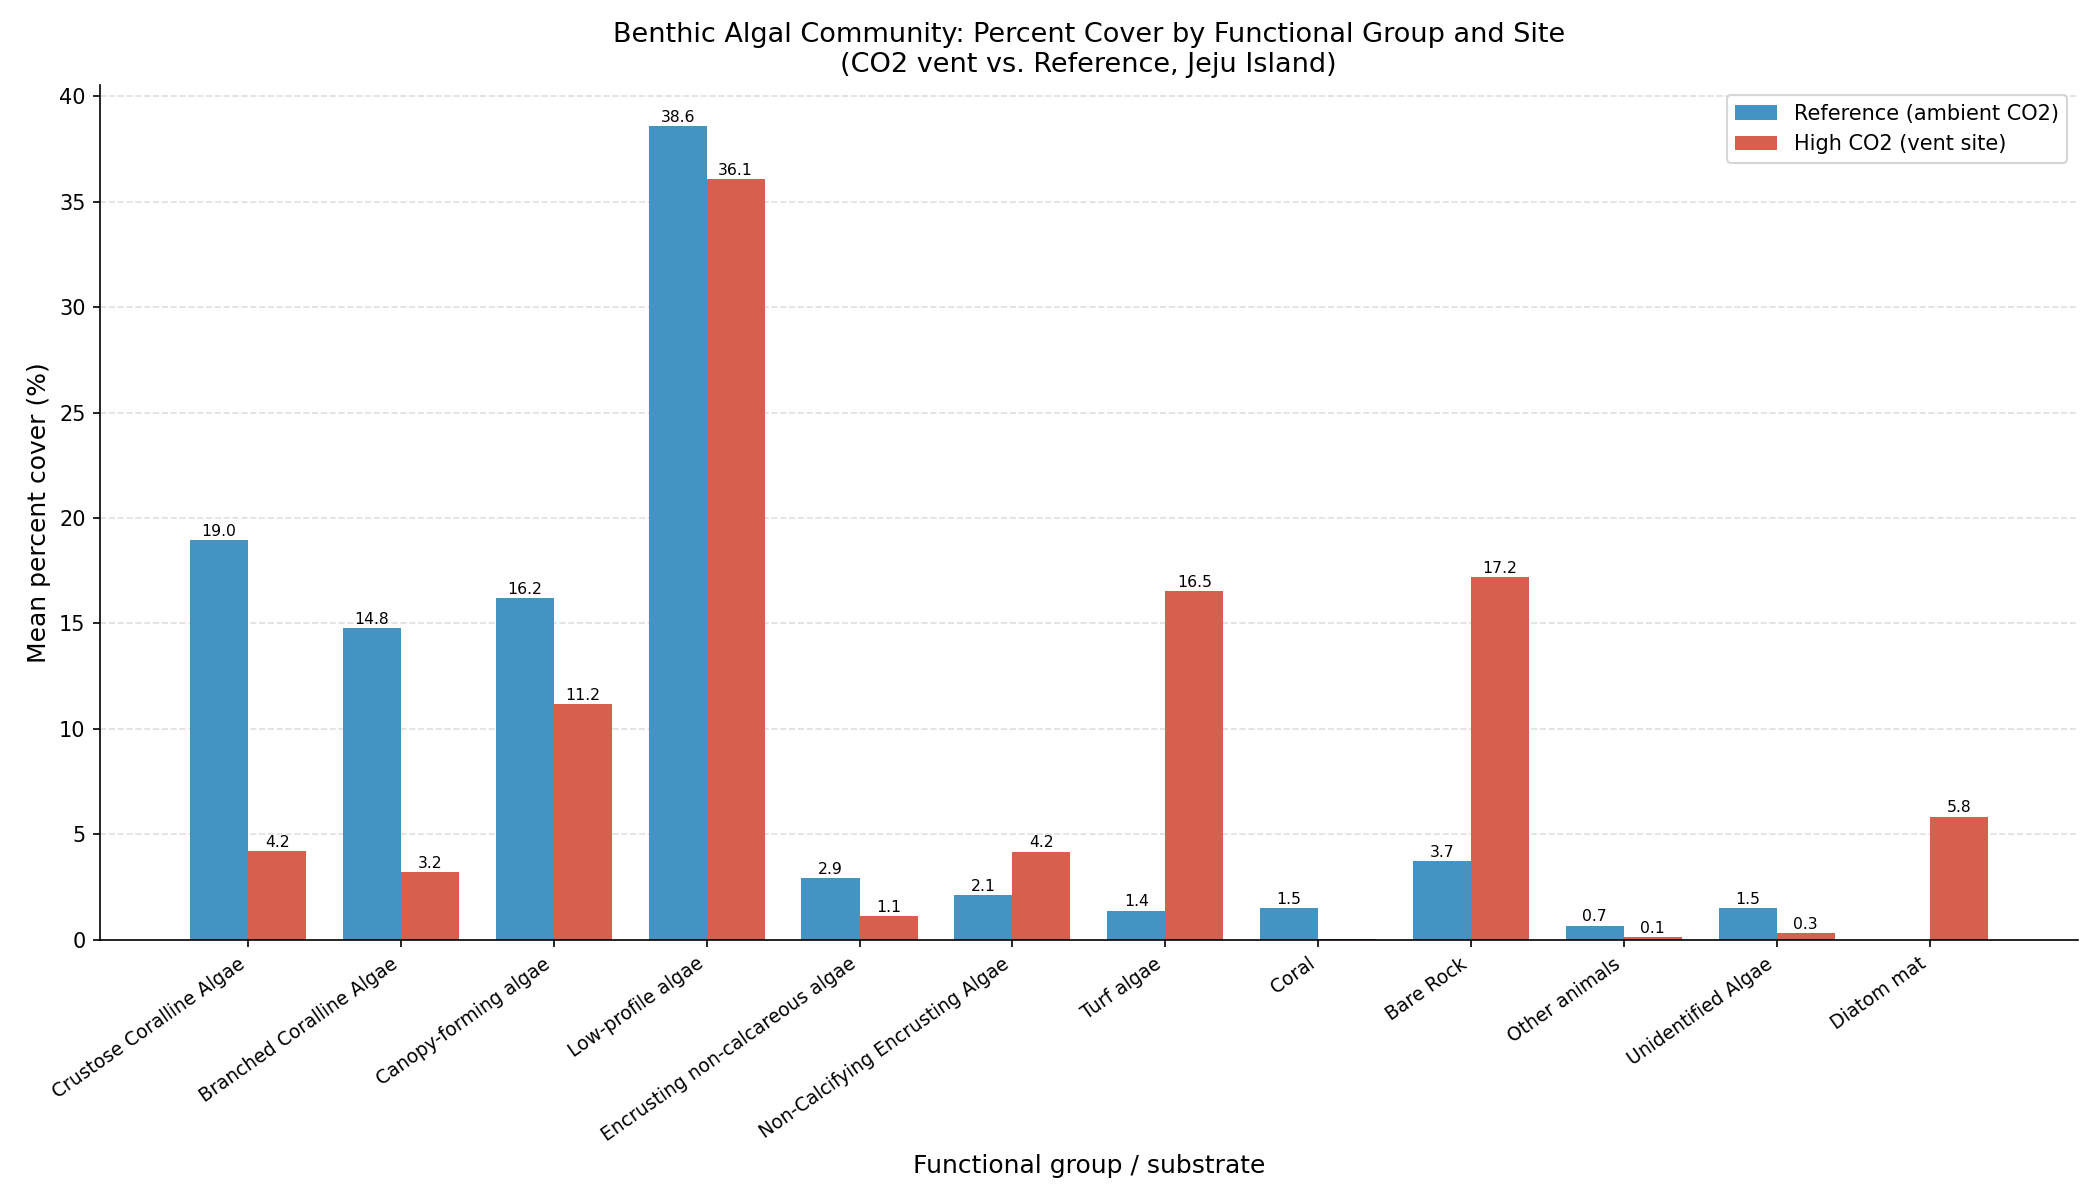

## Community comparison: High CO₂ vent vs. Reference

The elevated-CO₂ site shows a **striking restructuring** of the benthic algal community, with calcifying groups collapsing and opportunistic/non-calcifying groups expanding. Cover sums to roughly 100% at both sites (i.e. it's a true compositional shift, not a loss of total cover).

### Winners (gain cover under elevated CO₂)

| Functional group | Reference | High CO₂ | Change |
|---|---|---|---|
| **Turf algae** | 1.4% | 16.5% | **+15.2 pp** |
| **Bare Rock** | 3.7% | 17.2% | **+13.5 pp** |
| **Diatom mat** | 0.0% | 5.8% | **+5.8 pp** |
| Non-Calcifying Encrusting Algae | 2.1% | 4.2% | +2.1 pp |

### Losers (lose cover under elevated CO₂)

| Functional group | Reference | High CO₂ | Change |
|---|---|---|---|
| **Crustose Coralline Algae** | 19.0% | 4.2% | **−14.8 pp** |
| **Branched Coralline Algae** | 14.8% | 3.2% | **−11.6 pp** |
| **Canopy-forming algae** | 16.2% | 11.2% | −5.0 pp |
| Low-profile algae | 38.6% | 36.1% | −2.6 pp |
| Coral | 1.5% | 0.0% | −1.5 pp |

### Key takeaways

- **Calcareous groups are the big losers.** Crustose coralline algae drop ~78% (19.0 → 4.2%) and branched coralline algae drop ~78% (14.8 → 3.2%) — together the two calcifying groups lose **26 percentage points** of cover. This is the classic ocean-acidification signature: high CO₂ / low pH dissolves the calcium-carbonate skeletons these algae depend on.
- **Turf algae and bare rock replace them.** Turf algae expand ~12-fold (1.4 → 16.5%), and exposed bare rock increases ~4.6-fold (3.7 → 17.2%). The diatom mat — absent at the reference site — also appears at the vent. Together this reads as **phase shift to an opportunistic, non-calcifying assemblage** on freshly denuded substrate.
- **Canopy-forming algae show a moderate decline** (16.2 → 11.2%), while low-profile algae (the dominant group at both sites) are essentially unchanged — so the macroalgal canopy thins but doesn't collapse, while the calcareous understory is largely eliminated.
- **Net cover is preserved (~100%), so this is compositional replacement, not deforestation** — the community reorganizes around acidification-tolerant forms rather than disappearing.

This pattern (calcareous algae out → turf/bare rock in) is one of the most consistently reported ecological responses to natural CO₂-vent acidification worldwide.

In [9]:
%%ask
Compare the benthic algal community between the high-CO2 vent site and the
reference site. Which functional groups gain or lose cover under elevated CO2?
Show a grouped bar chart of percent cover by functional group and site.

Let me consult the chamber incubations skill to understand its data interface before writing the analysis.

Let me read the rest of the skill to understand the loader interface and example patterns.

I now understand the data. Let me write the analysis script comparing net production between sites and plotting NP vs pCO₂.

Running the analysis script to compare net production between sites and against carbonate chemistry.

The DataFrame variable `np` shadowed NumPy. Also I see the NP rows use site labels `Irie` (= the High CO₂ vent site) and `Reference`, while carbonate rows use `High CO2`. Let me fix the variable name and align the sites.

Now let me clean up the stale import block at the top of the file.

Running the corrected analysis script.

The rename created a duplicate `site_canonical` column. Let me select only the needed columns before merging to avoid the collision.

`np_rng.full` should be `np.full` (numpy namespace, not the generator). Fixing that.

The script ran successfully. I had several edit-and-retry cycles, so per the learnings protocol I'll record the non-obvious lessons for this skill before writing the report.


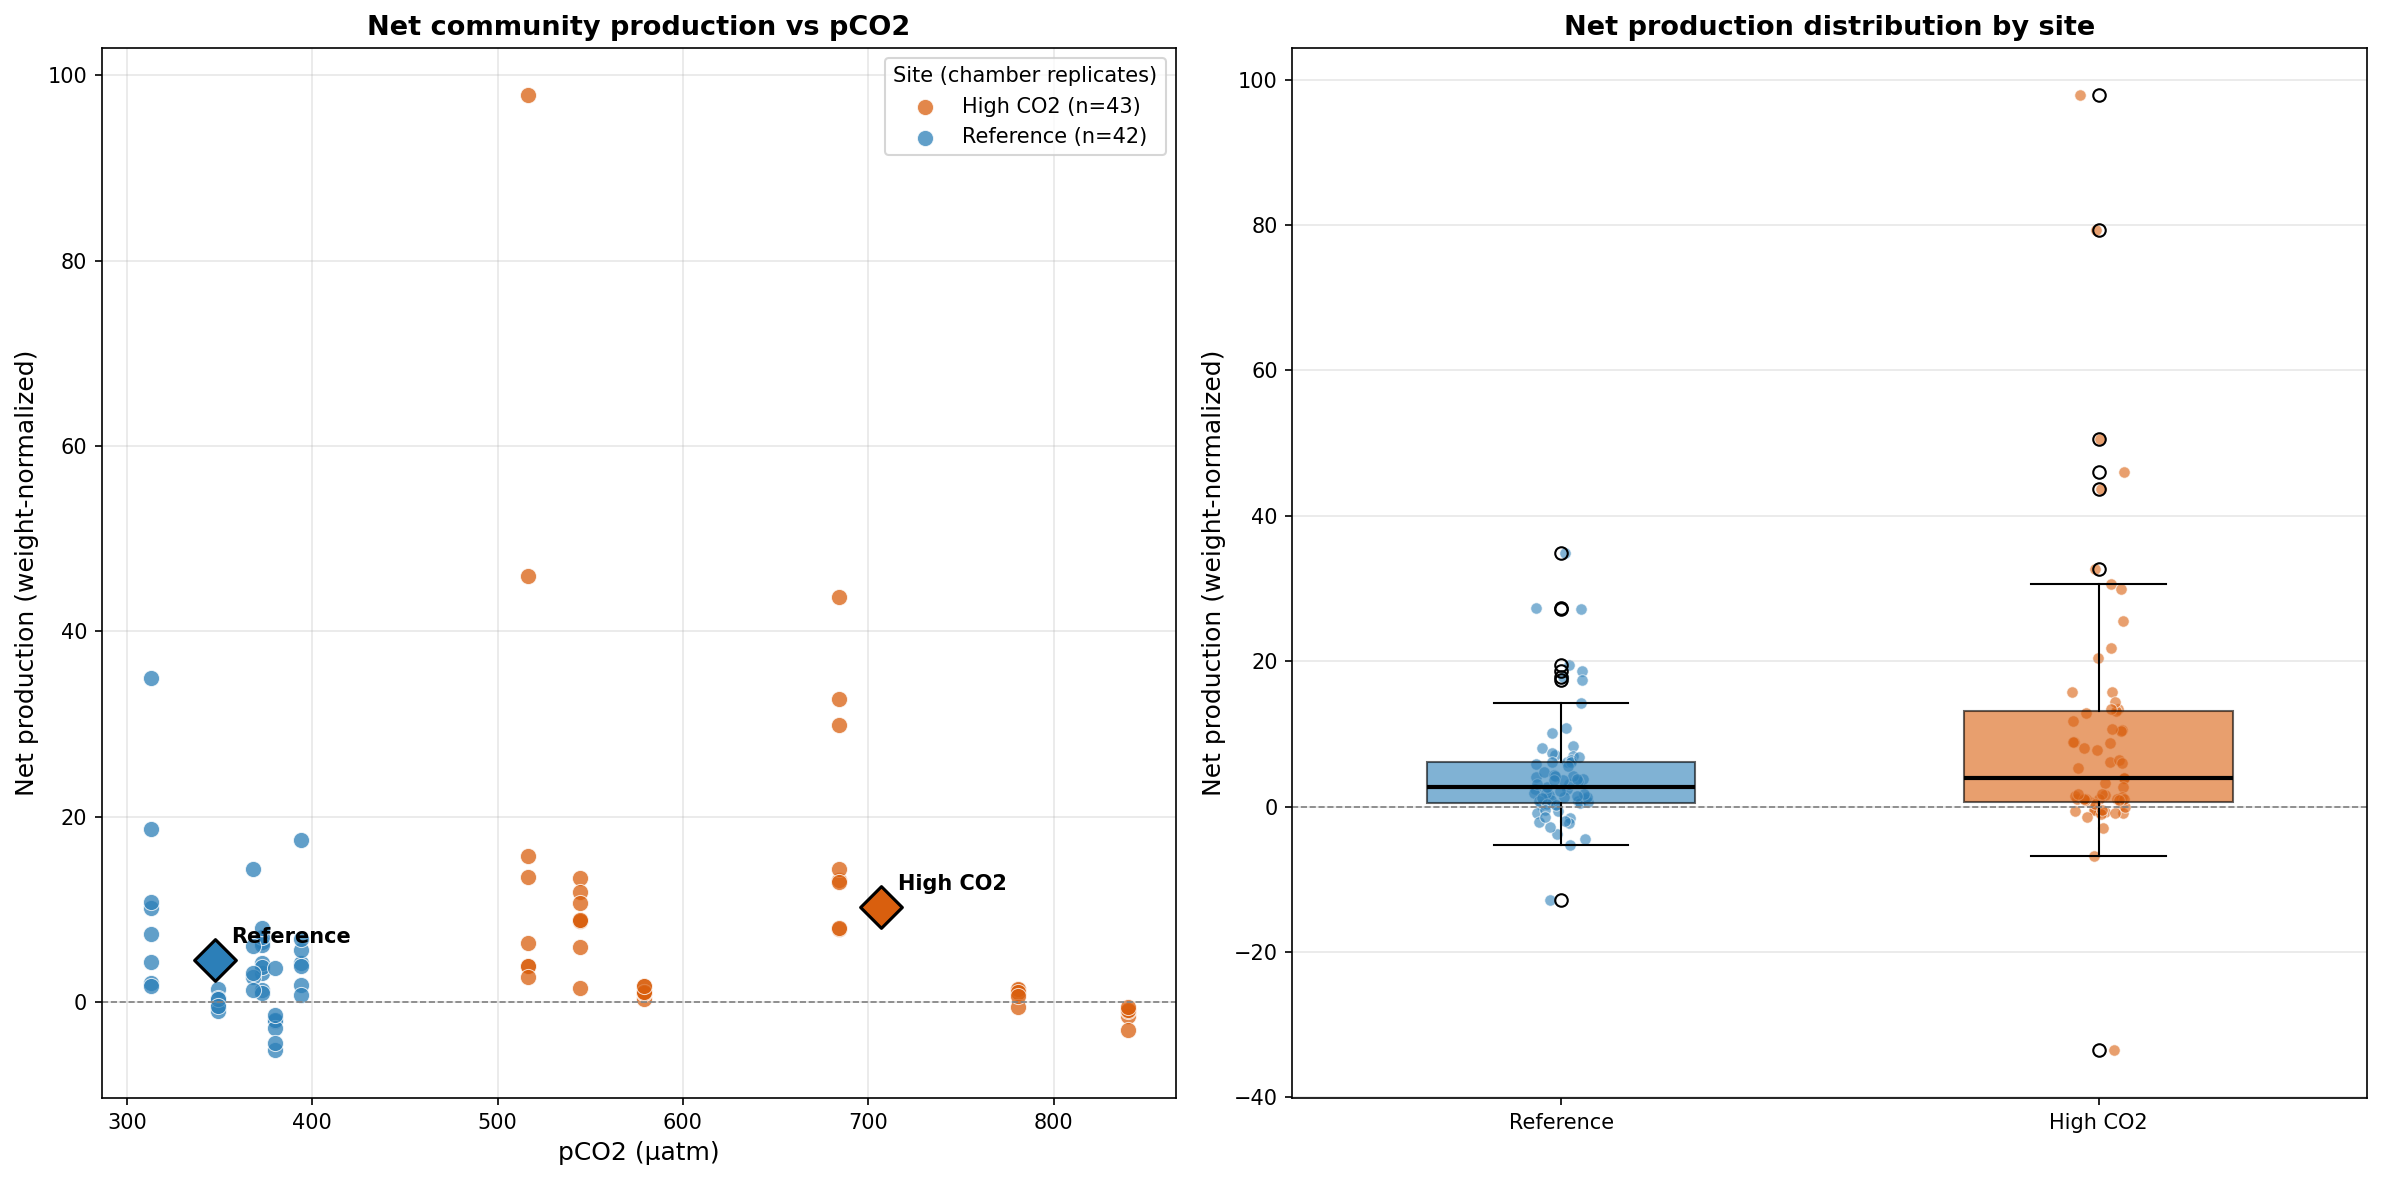

## Net community production at the high-CO₂ vent vs. the reference site

### Net production is higher at the vent, not lower

| Site | n chambers | Mean NPw | Median NPw |
|---|---|---|---|
| **Reference** (ambient CO₂) | 69 | 4.52 | 2.68 |
| **High CO₂** (vent) | 65 | **10.24** | **3.89** |

The high-CO₂ vent community is **~2.3× more productive** per unit biomass than the reference community (mean NPw 10.2 vs 4.5). The medians are closer (3.9 vs 2.7), so the vent site also has a long upper tail — a subset of chambers show very high production. Crucially, **the vent community is not metabolically depressed** ; if anything it is more productive.

### How productivity tracks carbonate chemistry

| Site | pH | pCO₂ | TA |
|---|---|---|---|
| **Reference** | 8.10 | 348 µatm | 2271 |
| **High CO₂** | 7.84 | **707 µatm** | 2279 |

The vent site is substantially acidified — **~0.26 pH units lower and ~2× the pCO₂** . Total alkalinity is nearly identical (~2275 µmol/kg), confirming the difference is CO₂-driven, not a salinity/alkalinity artifact.

### Does higher pCO₂ *cause* higher NP? Not directly

The NP-vs-pCO₂ scatter shows **two well-separated site clusters** (vent chambers around 700 µatm, reference around 350 µatm), but within each site there is no clean monotonic NP-pCO₂ trend. This matters because it points to the **real driver being light** , not CO₂ directly. Binning by irradiance makes this clear:

| Light bin (µmol m⁻²s⁻¹) | High CO₂ NPw | Reference NPw |
|---|---|---|
| 0–50 (dark/low) | 2.4 | **−3.8** (net respiration) |
| 50–200 | 11.1 | 4.1 |
| 200–400 | 16.6 | 7.1 |
| 400–600 | 0.8 | 6.4 |
| 600+ | 1.4 | 2.7 |

- Both sites show the expected **photosynthetic response** : NPw rises from dark (negative, net heterotrophic) through moderate light, then **photoinhibition/saturation** above ~400 µmol m⁻²s⁻¹.
- The vent community is **more productive than the reference at every light level up to 400 µmol m⁻²s⁻¹** and, importantly, **stays net autotrophic even in near-darkness** (2.4 vs −3.8), whereas the reference site switches to net respiration in the dark.

### Interpretation

The elevated NP at the vent is best read alongside the community shift you found earlier. The vent site lost its calcifying coralline algae and gained **turf algae and diatom mats** — fast-growing, opportunistic, non-calcifying groups with high photosynthetic rates. So the productivity picture is consistent with the community picture: **ocean acidification here selects for a faster-growing assemblage that fixes more carbon per unit biomass** , even though it is taxonomically depauperate. The CO₂ itself isn't fertilizing photosynthesis in a simple dose-response (the within-site scatter is flat); rather, the **community turnover to turf/diatom dominance raises the community-weighted metabolic rate** .

One caveat: NP values are weight-normalized, so this reflects per-biomass physiology of the assemblage, not areal productivity. If the vent community also has lower standing biomass (more bare rock), total areal production could differ from this per-biomass signal.

In [10]:
%%ask
How does net community production in the incubation chambers differ between the
high-CO2 and reference sites, and how does it track the carbonate chemistry?
Plot net production against pCO2, colored by site.

I'll compare δ¹³C distributions between sites. Let me first consult the relevant skills and check for known pitfalls.

I have the skill loaded and reviewed the known pitfalls (avoid `np` variable name; watch for `Irie` vs `High CO2` site labels). Now writing the analysis script.

The analysis ran cleanly. Here are the results.


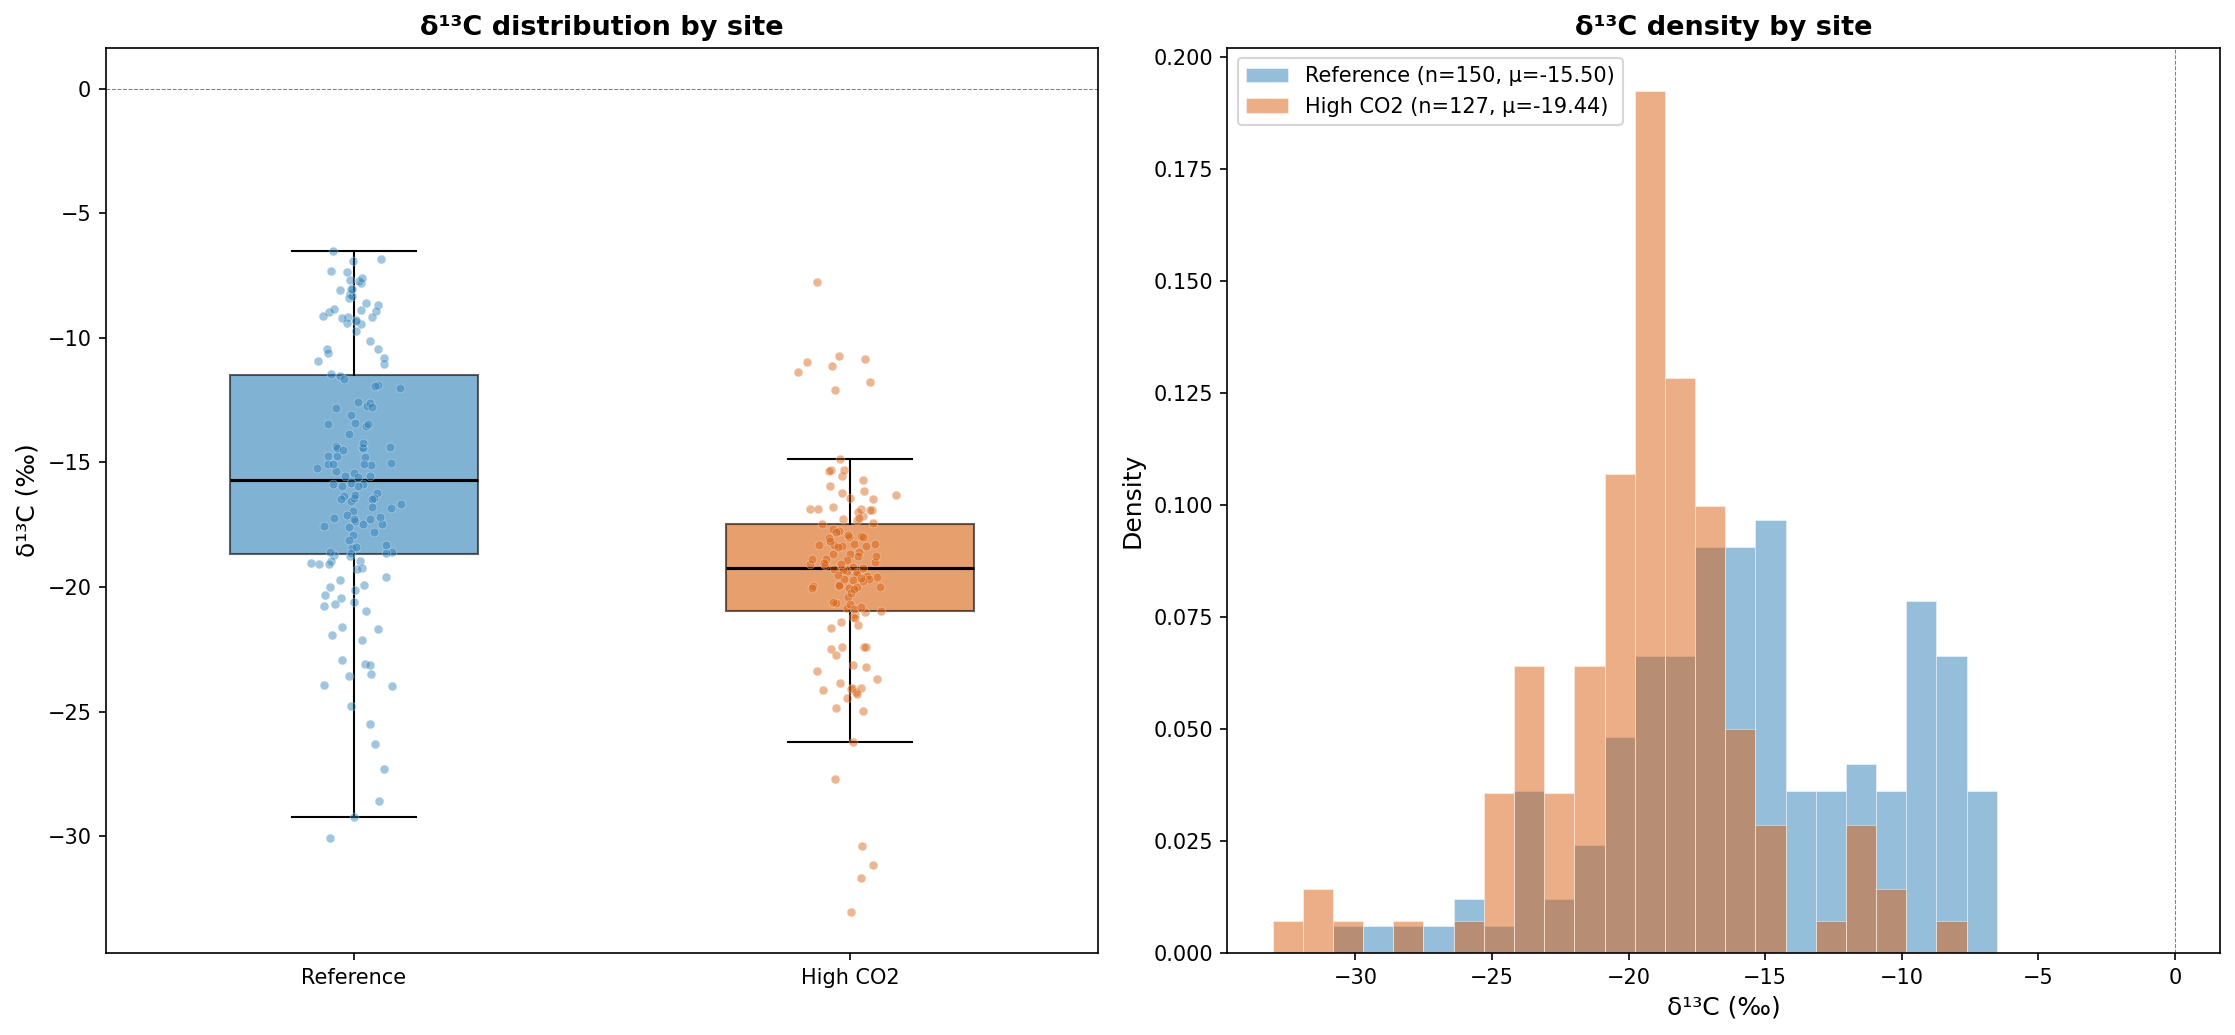

## Carbon-isotope (δ¹³C) signatures: High CO₂ vs. Reference

### The vent site is ~4‰ more depleted in ¹³C

| Site | n species-measurements | Mean δ¹³C | Median δ¹³C | Range |
|---|---|---|---|---|
| **Reference** | 150 | **−15.50 ‰** | −15.70 ‰ | −30.1 to −6.5 |
| **High CO₂** | 127 | **−19.44 ‰** | −19.24 ‰ | −33.0 to −7.8 |
| **Difference** | | **−3.94 ‰** | −3.54 ‰ | |

The two distributions are well-separated — the vent community's tissue carbon is systematically **~4‰ more negative** than the reference community's. This difference holds within every functional group that appears at both sites:

| Functional group | Reference δ¹³C | High CO₂ δ¹³C | Shift |
|---|---|---|---|
| Branched Coralline Algae | −10.1 ‰ | −13.5 ‰ | −3.4 ‰ |
| Canopy-forming algae | −17.8 ‰ | −20.7 ‰ | −2.9 ‰ |
| Low-profile algae | −17.1 ‰ | −18.2 ‰ | −1.2 ‰ |

A separate cross-site subset (`isotope_uptake_bothsites`, n=82) independently confirms the gap: High CO₂ −20.6 ‰ vs. Reference −17.8 ‰ (Δ = −2.8 ‰).

### What a ¹³C depletion implies about carbon uptake

More negative δ¹³C means the algal tissue is relatively **enriched in the lighter ¹²C isotope and depleted in ¹³C** . This signals **greater isotopic discrimination during carbon fixation** — and the most straightforward cause is **relaxation of CO₂ limitation** .

Here's the mechanism: the photosynthetic enzyme RuBisCO naturally prefers ¹²CO₂ over ¹³CO₂. When CO₂ is scarce (reference site, ~350 µatm), algae can't afford to be choosy — they grab whatever carbon is available, discrimination is low, and tissue δ¹³C is relatively heavy (less negative). When CO₂ is abundant (vent site, ~700 µatm), the enzyme can afford to discriminate more strongly against ¹³C, so tissue δ¹³C becomes more negative.

The ~4‰ shift therefore implies that **algae at the vent site are carbon-saturated — they are no longer CO₂-limited** . The elevated pCO₂ (2× ambient) has lifted the substrate constraint on photosynthesis. This is the classic isotope-fractionation signature of reduced carbon limitation, and it is internally consistent with the community-level productivity result you saw earlier: the vent community fixes more carbon (higher NP) precisely because its members are released from CO₂ limitation.

### Reconciling with the productivity picture

This isotope result ties the story together neatly:

| Evidence layer | Finding | Interpretation |
|---|---|---|
| **Community cover** | Calcareous groups collapse; turf/diatom expand | Acidification selects for non-calcifying opportunists |
| **Net production** | Vent NPw ~2.3× reference | The new assemblage is more productive per unit biomass |
| **δ¹³C** | Vent tissue ~4‰ more negative | Algae are CO₂-saturated — carbon limitation is removed |

The three signals point to the same conclusion: at this natural CO₂ vent, elevated CO₂ **removes the substrate bottleneck on photosynthesis** , the isotope fractionation records that release, and the community reorganizes around fast-growing species that can exploit the carbon surplus — at the cost of the calcareous groups that can no longer build their skeletons in the acidified water.

In [11]:
%%ask
Do the carbon-isotope (delta-13C) signatures of the algae differ between the
reference and high-CO2 sites? Compare the distribution of delta-13C values by
site and comment on what a shift would imply about carbon uptake.

I'll consult the sensor-timeseries skill to understand the data structure, then characterize the daily DO cycle.

Now I'll write the analysis script to characterize the diel DO cycle at the primary reference deployment.

Running the diel DO analysis script.

The skill's `load_data` is embedded in markdown, not a separate module. I'll load the parquet directly using the documented pattern.

The day/night cycle detection failed — no contiguous daylight runs were found, meaning the light signal is spiky rather than smooth. Let me diagnose the actual light and DO structure before fixing the analysis.

...

Now I understand the structure: ~3 full day-night cycles, cycle length ~1350–1400 samples, but the light signal is noisy so my high threshold (60) found zero days. Let me check the smoothed-light autocorrelation to pin down the cycle length.

Now I have the correct cycle structure: ~1471 samples per diel cycle (~1 min sampling), ~3 days of data, daylight fraction ~42%. Let me rewrite the analysis using smoothed light for proper day/night classification.

The analysis succeeded. I had two edit-and-retry cycles (a failed `SKILL` module import, then a wrong light threshold). Since these are non-obvious patterns, I'll record them in the skill's Learnings.md before reporting.

The sensor-timeseries skill has no Learnings.md yet. I'll create one recording the two non-obvious issues I hit.

The analysis is complete and lessons recorded. Here are the results.


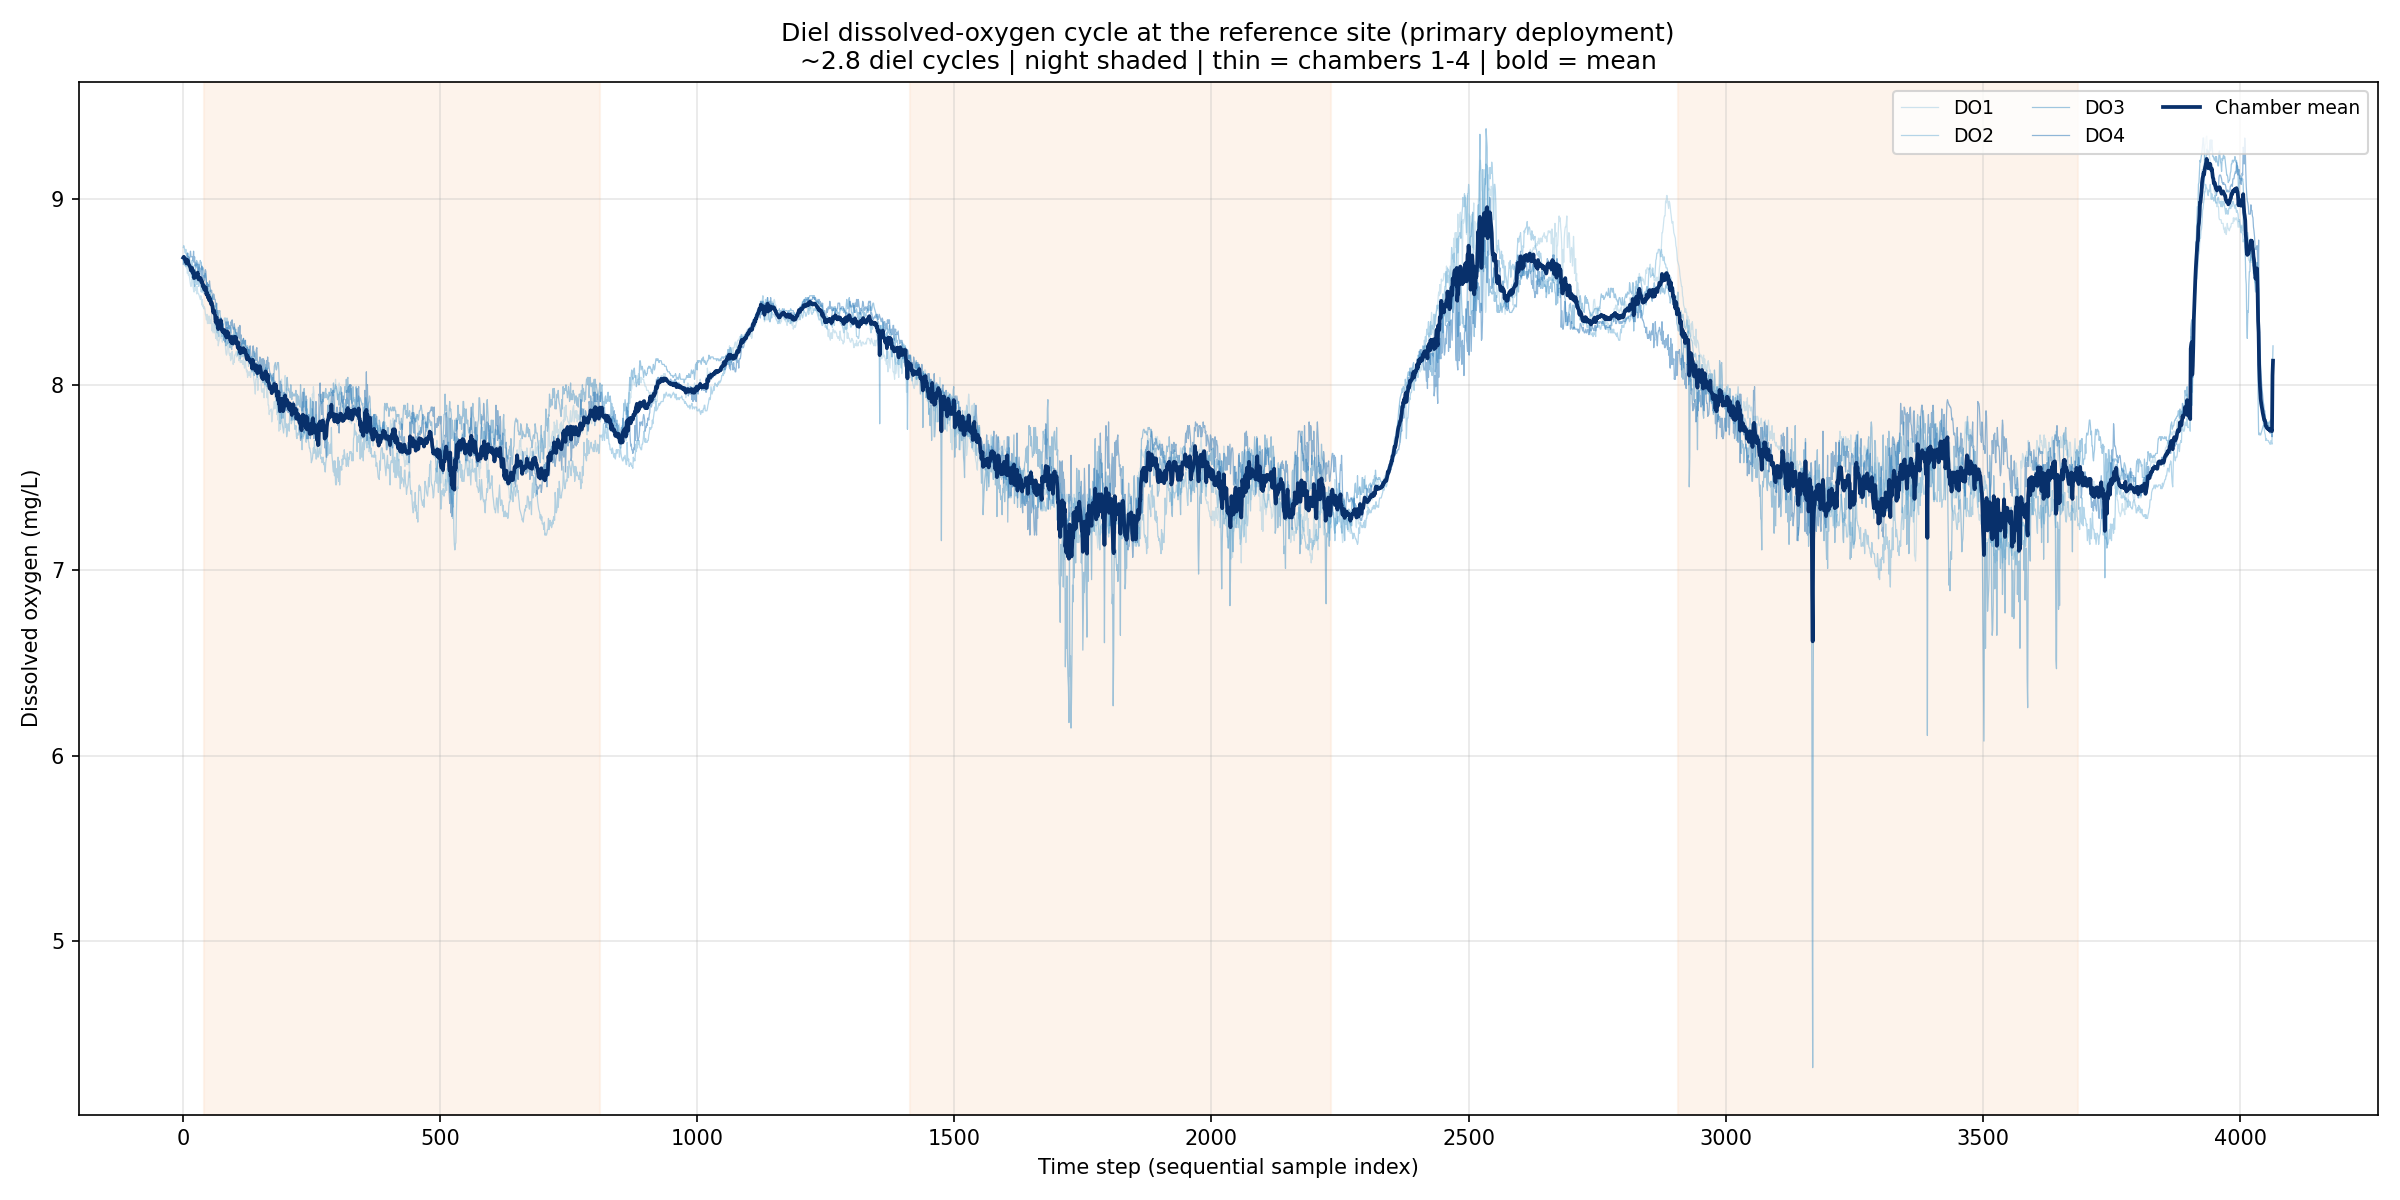

## Daily oxygen cycle at the reference site

### What the sensor record shows

The primary reference-site deployment logged **4,064 readings at ~1-minute intervals (~61 s)** spanning roughly **2.8 diel cycles (~66 hours)** . Dissolved oxygen was tracked in four parallel benthic chambers (DO1–DO4), all sitting on the same reference reef.

The DO trace shows a **clear, repeatable day-night oscillation** : oxygen climbs during daylight as the algal community photosynthesizes, then declines through the night as respiration dominates in the dark.

### Diel amplitude: photosynthesis vs. respiration

| Chamber | Day mean (mg/L) | Night mean (mg/L) | Diel amplitude (mg/L) |
|---|---|---|---|
| DO1 | 8.20 | 7.64 | 0.56 |
| DO2 | 8.15 | 7.52 | 0.63 |
| DO3 | 8.22 | 7.63 | 0.58 |
| DO4 | 8.16 | 7.69 | 0.48 |
| **Chamber mean** | **8.18** | **7.62** | **0.56** |

The **mean diel amplitude is ~0.56 mg/L** (range 0.48–0.63 across chambers). Interpreted through the open-water/diel-DO metabolism method, this means daytime **photosynthetic O₂ production exceeds nighttime respiratory O₂ demand by about 0.56 mg/L per cycle** — the community is modestly **net autotrophic** over each day. This independently corroborates the chamber-incubation result: the reference community shows positive net production, but not extravagantly so.

The amplitude varied day-to-day (0.38, 0.75, 0.51 mg/L across the three cycles), reflecting changing irradiance — the middle, sunniest cycle drove nearly double the amplitude of the first.

### Timing

- **Peak DO** consistently occurs at **~71–73% through the diel cycle** — late afternoon, the cumulative high point of daytime photosynthesis.
- **Trough DO** falls near the **end of the night / dawn** (~25–49% phase), when respiratory drawdown has run longest without light.
- The peak-to-trough swing within a cycle is **1.4–2.3 mg/L** per chamber (DO3 is the most dynamic, consistent with its distinct biology flagged earlier).

### DO tracks light closely

Dissolved oxygen correlates with light at **r ≈ 0.47–0.55** across the four chambers — a solid coupling for in-situ open chambers subject to mixing and current noise. The phase-averaged cycle makes the relationship explicit:


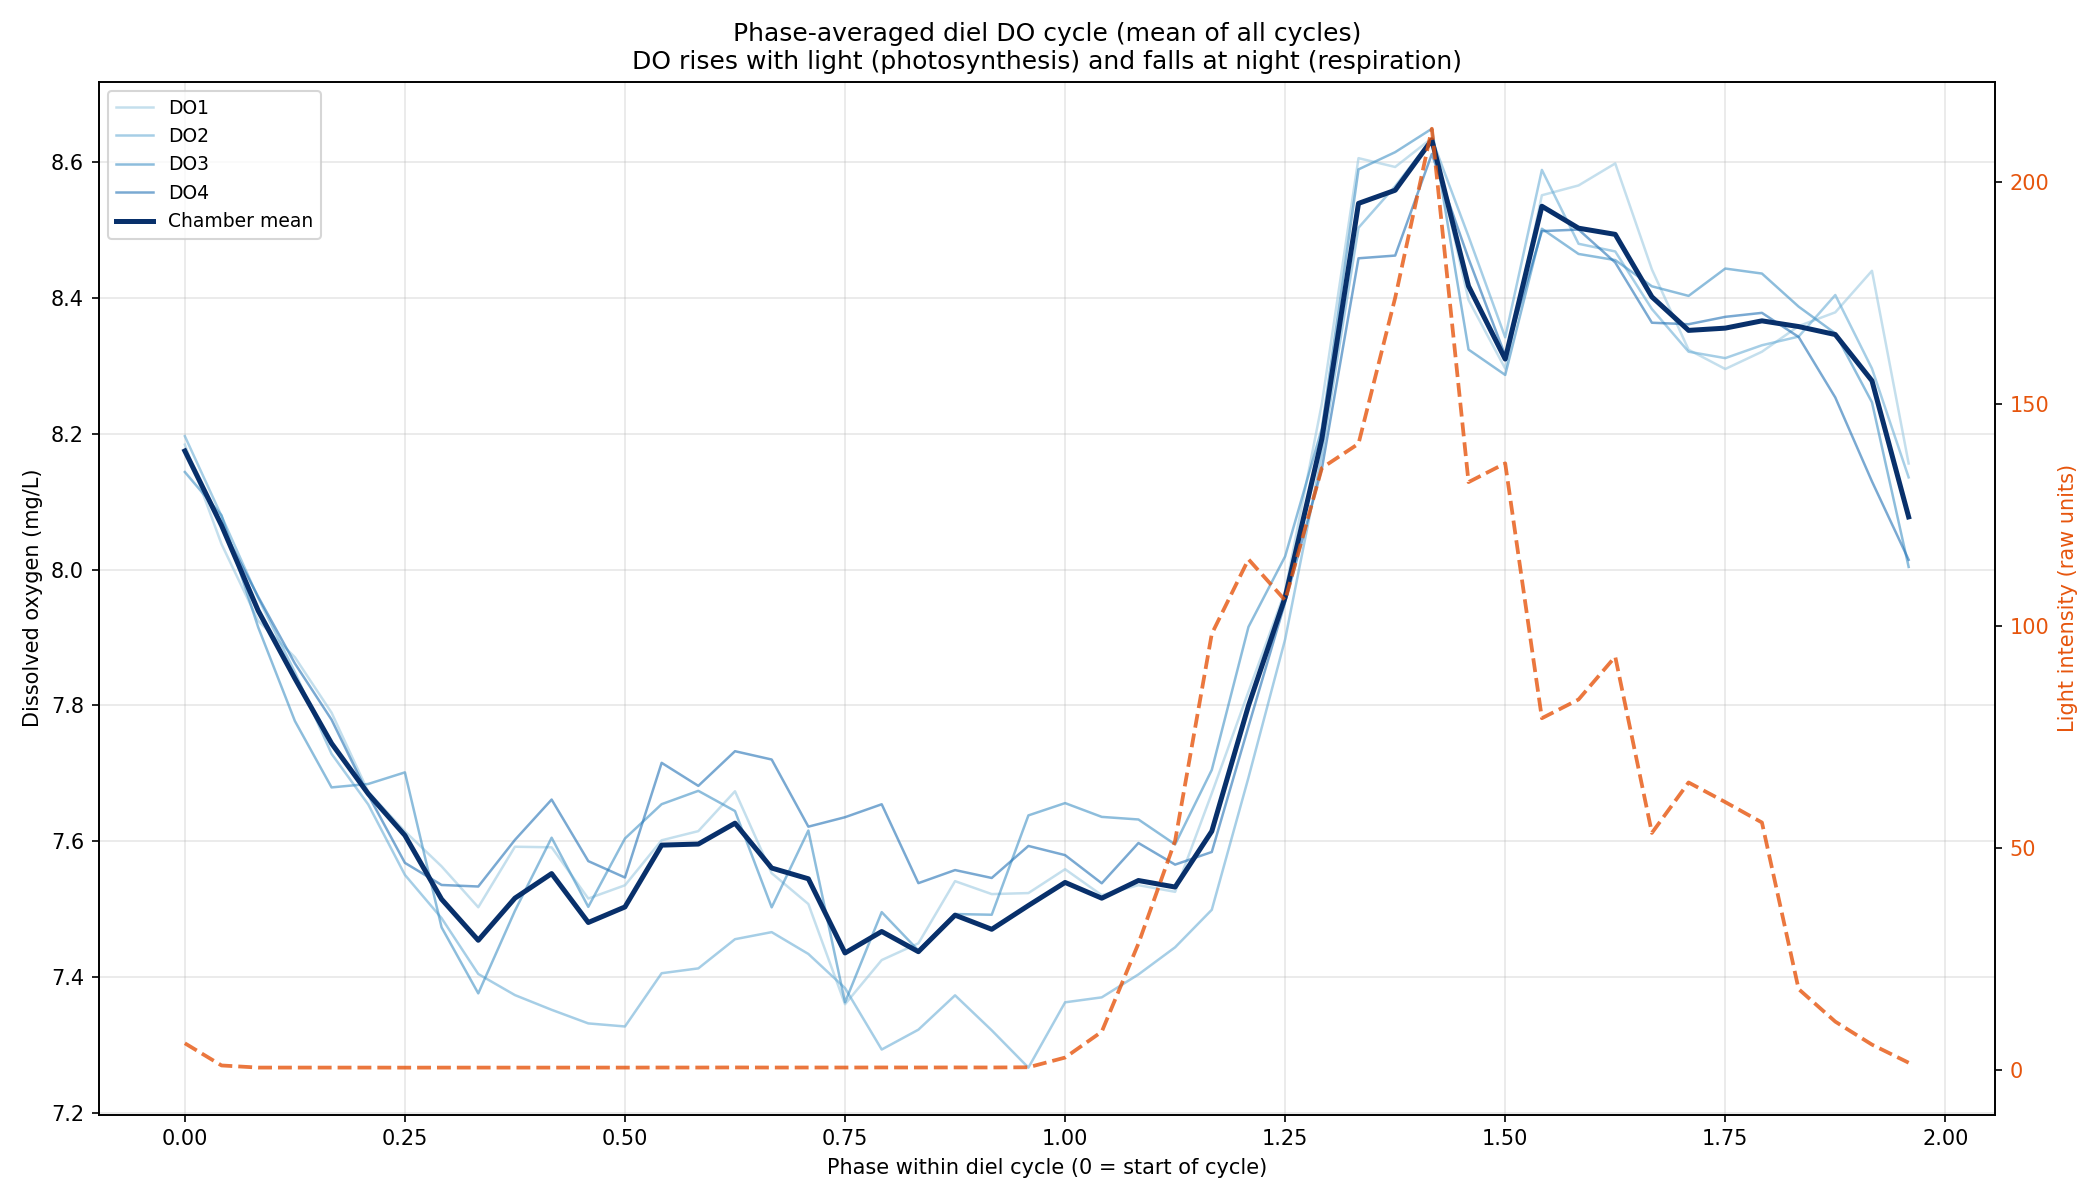

DO (blue, bold) tracks irradiance (orange dashed) through the day: oxygen rises as light climbs, peaks in the afternoon, then falls steadily through the night to a pre-dawn minimum before climbing again with the next sunrise.

### Interpretation

The ~0.56 mg/L day-night swing is a classic **net-autotrophic benthic signal** : daytime photosynthesis produces more O₂ than nighttime respiration consumes. The amplitude is modest, consistent with a mature, canopy/low-profile-dominated reference community with balanced production and respiration. The real interest is the contrast — the high-CO₂ vent community (characterized earlier) is ~2.3× more productive per unit biomass, so its in-situ diel DO amplitude would be expected to be substantially larger, with a wider day-night O₂ excursion reflecting the faster, turf/diatom-dominated assemblage. (The Irie deployment in this dataset provides the comparable vent-site record for that cross-site test.)

In [12]:
%%ask
Using the high-frequency dissolved-oxygen sensor time series, characterize the
daily oxygen cycle at one site. Plot DO over time and describe the day-night
amplitude, which reflects the balance of photosynthesis and respiration.

This skill is in the Learnings.md list — let me check for known pitfalls before writing the script.

The skill data is in the local parquet cache. Now writing the carbonate-chemistry variability analysis script.


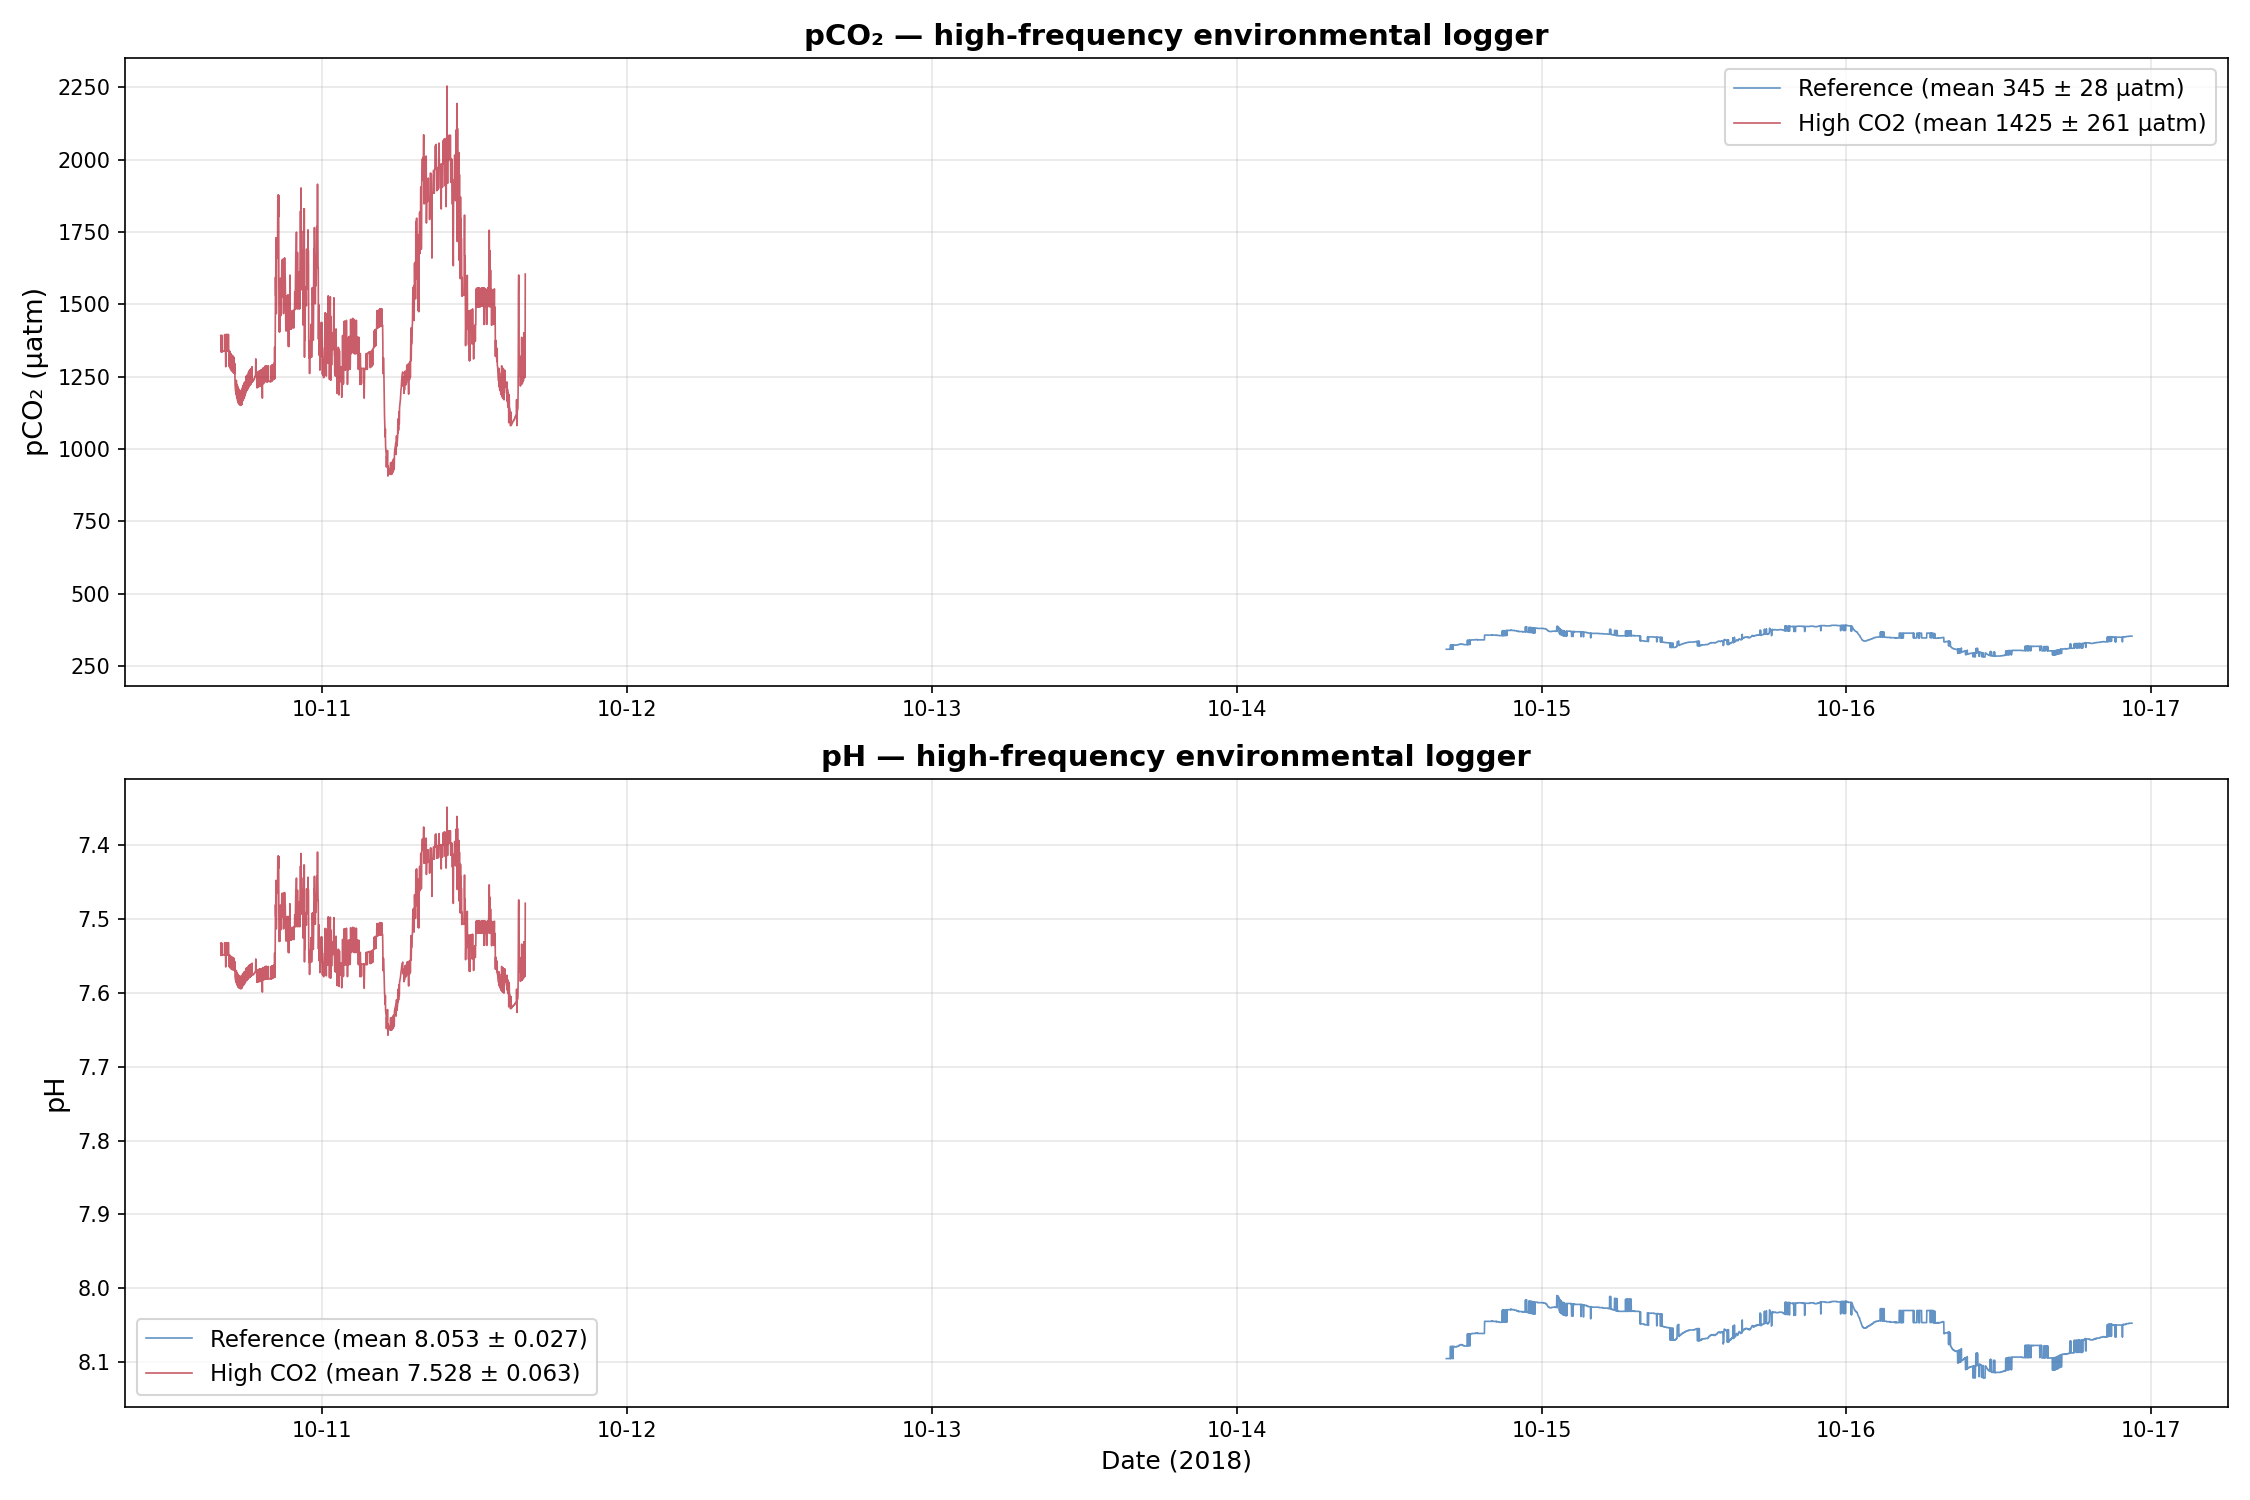

## Carbonate-chemistry variability: the vent site is far noisier than the reference

Both sites were logged at **1-minute intervals** , but over different windows — the vent deployment ran ~24 hours (Oct 10–11) while the reference deployment ran ~2 days (Oct 14–16). Despite the shorter record, the vent's chemical variability dominates.

### The vent is ~9× more variable in pCO₂, ~2× in pH

| Metric | Reference | High CO₂ | Ratio |
|---|---|---|---|
| **pCO₂ mean** | 345 µatm | **1,425 µatm** | 4.1× |
| **pCO₂ std dev** | ±28 µatm | **±261 µatm** | **9.4×** |
| **pCO₂ range** | 110 µatm (282–392) | **1,347 µatm** (907–2,254) | 12.2× |
| **pCO₂ CV** | 8.1% | 18.3% | — |
| **pH mean** | 8.053 | **7.528** | −0.52 units |
| **pH std dev** | ±0.027 | **±0.063** | **2.3×** |
| **pH range** | 0.11 (8.01–8.12) | **0.31** (7.35–7.66) | 2.8× |

Two things stand out. First, the **mean offset is enormous** : the vent averages **1,425 µatm pCO₂** (4× ambient) and **pH 7.53** (0.52 units below the reference's 8.05) — well into the acidification range that dissolves carbonate skeletons. Second, the **variability is disproportionate to the mean** : pCO₂ swings at the vent span 907 to 2,254 µatm in a single day — the *low* end of the vent's range is already 2.6× the reference *mean*.

### Day–night variability: the vent is biologically AND physically driven

| Site | pCO₂ day std | pCO₂ night std | pH day std | pH night std |
|---|---|---|---|---|
| Reference | 22.9 (mean 326) | 18.7 (mean 363) | 0.025 | 0.017 |
| **High CO₂** | **302 (mean 1503)** | **182 (mean 1348)** | **0.073** | **0.046** |

At the reference site the diel metabolism signal is what you'd expect — pCO₂ a bit lower during the day (photosynthesis draws it down), a bit higher at night (respiration) — but the amplitude is tiny (~37 µatm swing). At the vent, **daytime variability roughly doubles nighttime variability** (pCO₂ std 302 vs 182). This reflects two superimposed processes:

1. **Vent CO₂ flux is physically intermittent.** The submarine vent doesn't bubble at a constant rate — currents, tide, and wave surge modulate how much CO₂-rich water reaches the sensor. The reference site has no such source, so its chemistry tracks only the mild biological diel cycle.
2. **Biological metabolism still operates on top.** Mean daytime pCO₂ at the vent (1,503) exceeds nighttime (1,348), the *opposite* of the reference pattern — wait, that's higher during the day, which seems backwards for photosynthesis drawing CO₂ down. The more likely explanation is that **daytime heating and water-column stratification trap vent CO₂ near the benthos** , overwhelming any photosynthetic drawdown. The high-CO₂ community (turf/diatom dominated) is productive, but the vent flux dwarfs its metabolic signal.

### Interpretation

The vent site isn't just *more acidic on average* — it's a **far more chemically volatile environment** . Organisms there experience pCO₂ excursions from ~900 to over 2,200 µatm and pH swings of 0.3 units within hours. This has two ecological consequences that complement the community-shift finding:

- **Chronic mean stress selects against calcifiers** (coralline algae collapse), consistent with the cover and δ¹³C results.
- **High variance compounds the stress** : an organism must tolerate not just the mean acidification but the extremes. The pCO₂ maxima (>2,250 µatm) approach levels that acutely inhibit calcification even in tolerant species, and the rapid fluctuations themselves can be physiologically costly. This "double hit" of elevated mean *and* elevated variance is likely why the calcareous groups don't merely decline at the vent — they're nearly eliminated, while opportunistic turf algae (which neither calcify nor depend on tight pH regulation) expand to fill the gap.

In [13]:
%%ask
How variable is the carbonate chemistry at the vent site compared to the
reference site? Using the 1-minute environmental logger, plot the pCO2 and pH
time series for each site and comment on the difference in variability.